# CAR PRICE PREDICTION
## Objective:-
   Predict the selling price of a used car based on features such as brand, age, kilometers driven, fuel type, seller type, transmission, and ownership using machine learning regression models.

### STEP 1 -- Import libraries

In [64]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib for data visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced statistical visualization
import seaborn as sns

# Import warnings to ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import preprocessing tools
from sklearn.preprocessing import OneHotEncoder

# Import ColumnTransformer to apply encoding on categorical columns
from sklearn.compose import ColumnTransformer

# Import Pipeline to combine preprocessing and model
from sklearn.pipeline import Pipeline

# Import Machine Learning Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### STEP 2-- Load the dataset

In [123]:
# Read the CSV file
df = pd.read_csv("cardekho_dataset.csv")

# Display first five rows
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### STEP 3-- Display dataset shape & count missing values

In [130]:
# Display number of rows and columns
print("Dataset Shape :", df.shape)

Dataset Shape : (15411, 14)


In [131]:
# Count missing values in each column
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

### STEP 4-- Remove duplicates records & Statistical summary

In [132]:
# Display shape before removing duplicates
print("Before Removing Duplicates :", df.shape)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Display shape after removing duplicates
print("After Removing Duplicates :", df.shape)

Before Removing Duplicates : (15411, 14)
After Removing Duplicates : (15411, 14)


In [133]:
# Display statistical summary of numerical columns
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


### STEP 5-- Chect unique values from the coloumns

In [136]:
# Check unique values of categorical columns
print(df["brand"].unique())

print(df["model"].unique())

print(df["fuel_type"].unique())

print(df["seller_type"].unique())

print(df["transmission_type"].unique())

['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' 'Z4' '6' 'XF' 'X5' 'Hector' 'Civic' 'D-Max'
 'Cayenne' 'X1' 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300' 'Dzire VXI'
 'S90' 'WR-V' 'XL6' 'Triber' 'ES' 'Wrangler' 'Camry' 'Elantra' 'Yaris'
 'GL-Class' '7' 'S-Presso' 'Dzire LXI' 'Aura' 'XC' 'Ghibl

### STEP 6-- Feature Engineering 

In [138]:

# Drop Car_Name column
df.drop("car_name", axis=1, inplace=True)

In [140]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 1.5+ MB


### STEP 7-- Exploratory Data Analysis (EDA)

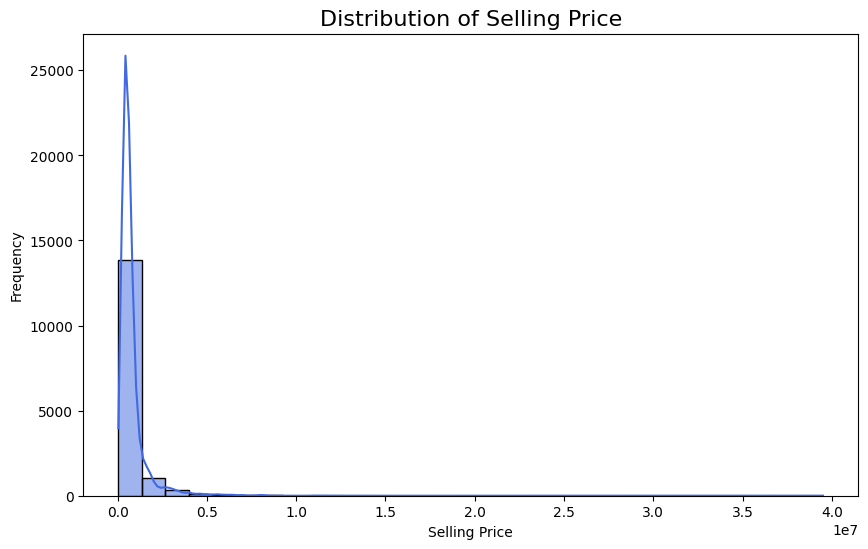

In [142]:
# DISTRIBUTION OF SELLING PRICE
# Create a figure with specified size
plt.figure(figsize=(10,6))

# Plot histogram with Kernel Density Estimate (KDE)
sns.histplot(df["selling_price"], bins=30, kde=True, color="royalblue")

# Add graph title
plt.title("Distribution of Selling Price", fontsize=16)

# Label X-axis
plt.xlabel("Selling Price")

# Label Y-axis
plt.ylabel("Frequency")

# Display the graph
plt.show()

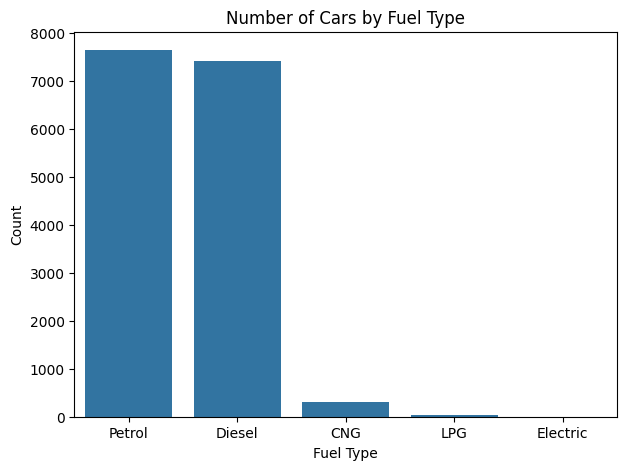

In [146]:
# COUNT OF FUEL TYPES
# Create figure
plt.figure(figsize=(7,5))

# Count plot for fuel types
sns.countplot(x="fuel_type", data=df)

# Add title
plt.title("Number of Cars by Fuel Type")

# Label axes
plt.xlabel("Fuel Type")
plt.ylabel("Count")

# Show graph
plt.show()

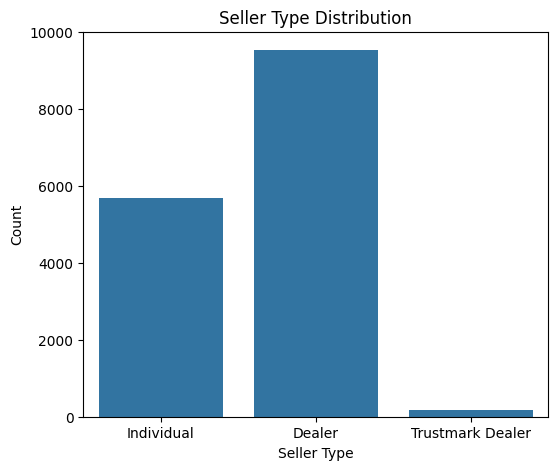

In [147]:
# COUNT OF SELLER TYPES
plt.figure(figsize=(6,5))

# Plot seller type counts
sns.countplot(x="seller_type", data=df)

plt.title("Seller Type Distribution")

plt.xlabel("Seller Type")
plt.ylabel("Count")

plt.show()

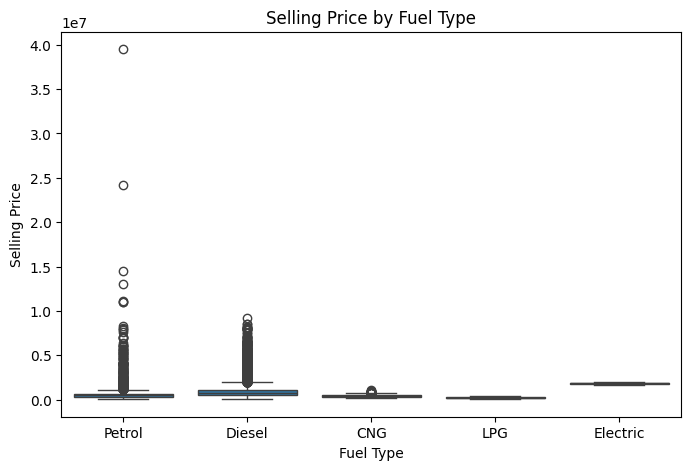

In [148]:
# SELLING PRICE VS FUEL TYPE
plt.figure(figsize=(8,5))

# Create box plot
sns.boxplot(x="fuel_type", y="selling_price", data=df)

plt.title("Selling Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Selling Price")

plt.show()

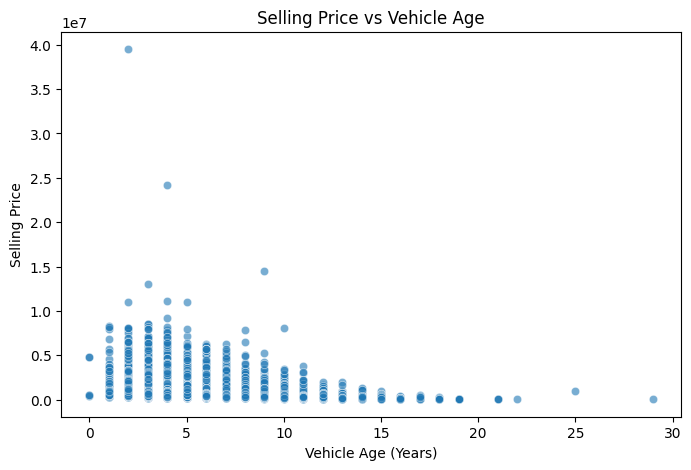

In [150]:
# SELLING PRICE VS Vehicle AGE
plt.figure(figsize=(8,5))

# Scatter plot
sns.scatterplot(
    x="vehicle_age",
    y="selling_price",
    data=df,
    alpha=0.6
)

plt.title("Selling Price vs Vehicle Age")

plt.xlabel("Vehicle Age (Years)")

plt.ylabel("Selling Price")

plt.show()

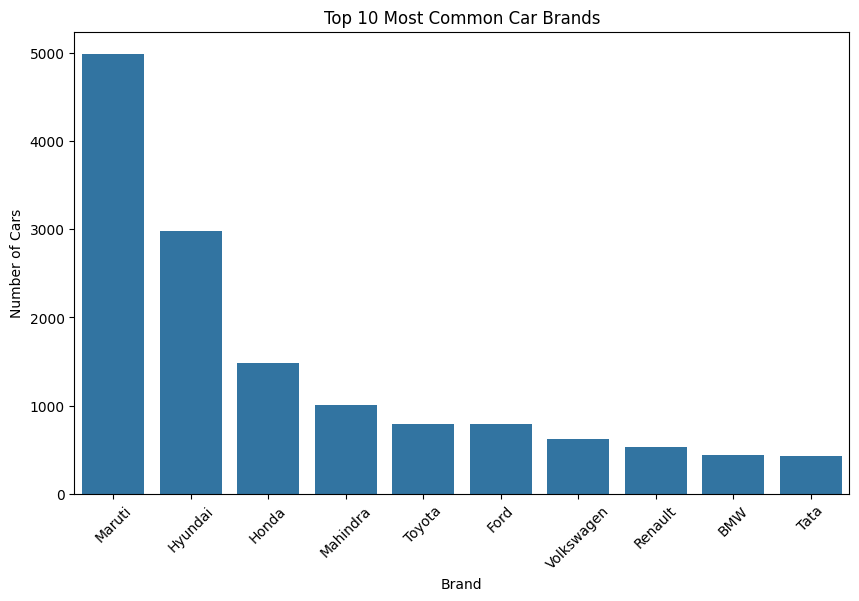

In [151]:
# TOP 10 CAR BRANDS
# Get top 10 brands
top_brands = df["brand"].value_counts().head(10)

# Create figure
plt.figure(figsize=(10,6))

# Plot bar chart
sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title("Top 10 Most Common Car Brands")

plt.xlabel("Brand")

plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()


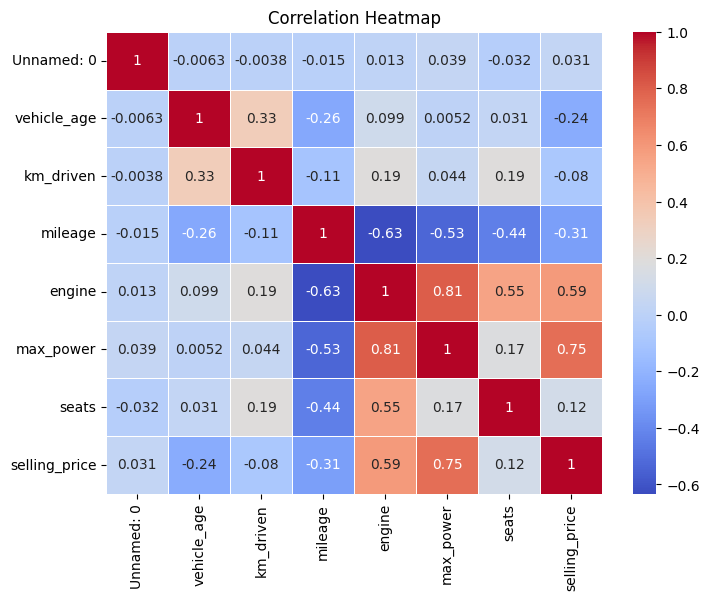

In [154]:
# CORRELATION HEATMAP
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Create figure
plt.figure(figsize=(8,6))

# Draw heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

##### Max Power has the strongest positive correlation with Selling Price (0.75), indicating that cars with higher engine power generally have higher selling prices.
##### Engine also shows a strong positive correlation with Selling Price (0.59), meaning larger engine capacity tends to increase the car's value.
##### Mileage has a moderate negative correlation with Selling Price (-0.31), suggesting that cars with higher mileage tend to have lower selling prices.
##### Vehicle Age has a weak negative correlation with Selling Price (-0.24), indicating that older cars generally sell for less.
##### Seats and Kilometers Driven have only a weak relationship with the selling price.

### STEP 8-- Machine Learning Model Building

In [152]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=['fuel_type', 'seller_type', 'transmission_type', 'model', 'brand'],
    drop_first=True
)

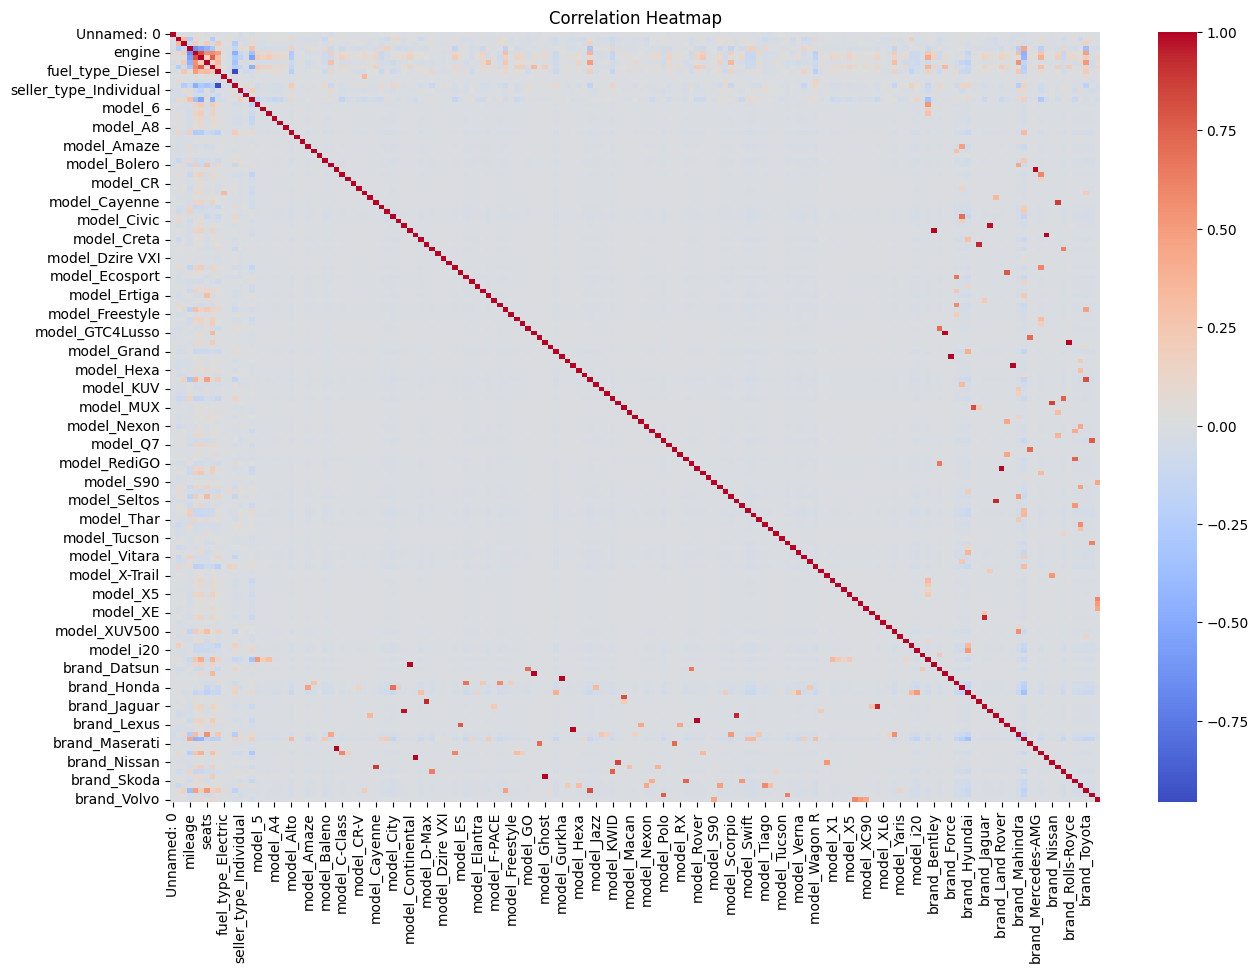

In [153]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [155]:
# Features (Independent Variables)
X = df.drop(['selling_price'],axis=1)

# Target Variable (Dependent Variable)
y = df["selling_price"]

# Display first five rows of features
X.head()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,...,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,0,9,120000,19.70,796,46.30,5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,5,20000,18.90,1197,82.00,5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,11,60000,17.00,1197,80.00,5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,9,37000,20.92,998,67.10,5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,6,30000,22.77,1498,98.59,5,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [156]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42
)

In [157]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Training and Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("="*50)
    print(name)
    print("="*50)
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")
    print()

Linear Regression
MAE : 177649.65
MSE : 150524396383.11
RMSE: 387974.74
R² Score: 0.8000

Random Forest
MAE : 95178.76
MSE : 47469945886.81
RMSE: 217875.99
R² Score: 0.9369

Gradient Boosting
MAE : 125584.62
MSE : 58234357293.96
RMSE: 241317.96
R² Score: 0.9226



In [170]:
# Store R² scores
scores = {
    "Linear Regression": 0.8060,
    "Random Forest Regressor": 0.9369,
    "Gradient Boosting Regressor": 0.9226
}

# Find the best model
best_model = max(scores, key=scores.get)

print("Best Model :", best_model)
print("R² Score   :", scores[best_model])

Best Model : Random Forest Regressor
R² Score   : 0.9369


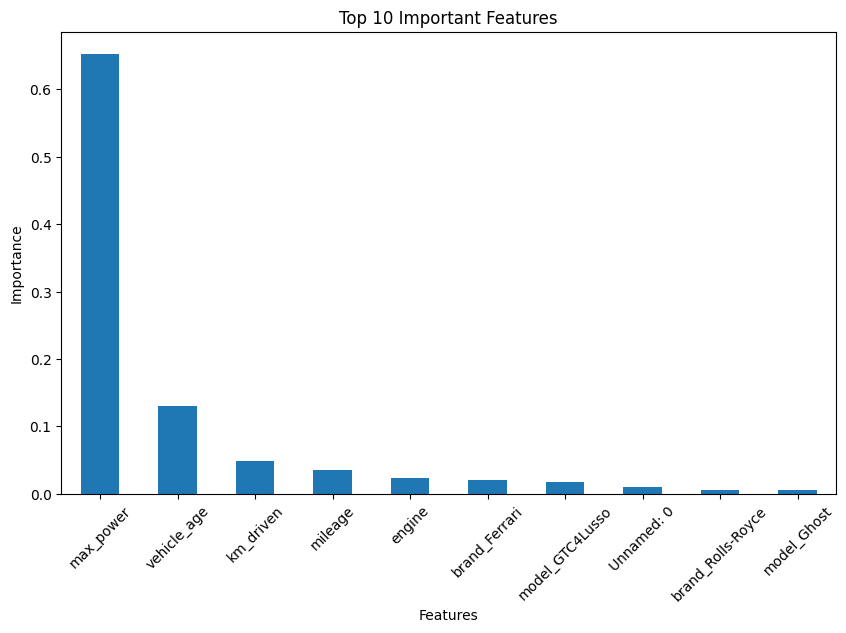

In [172]:
# Feature Importance using Random Forest
rf_model = models["Random Forest"]
import pandas as pd
import matplotlib.pyplot as plt

# Create a Series of feature importances
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Sort feature importances
feature_importance = feature_importance.sort_values(ascending=False)

# Plot the top 10 important features
plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

##### The Random Forest Regressor identified max_power as the most influential feature for predicting car selling prices, followed by vehicle_age, km_driven, mileage, and engine. These results indicate that the vehicle's performance and condition have the greatest impact on its resale value, while brand and model contribute to a lesser extent.

### Project Conclusion
##### This project developed a Car Price Prediction System using machine learning techniques. The dataset was cleaned by handling missing values, removing duplicate records, and encoding categorical variables using One-Hot Encoding. Exploratory Data Analysis (EDA) was performed to understand the relationships between different features and the selling price.
##### Three regression models—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—were trained and evaluated using MAE, MSE, RMSE, and R² Score. Among these models, the Random Forest Regressor achieved the best performance with an R² Score of 0.9369, making it the most accurate model for predicting used car prices.
##### Feature importance analysis showed that max_power, vehicle_age, km_driven, mileage, and engine were the most influential factors affecting the selling price. Overall, this project demonstrates that machine learning can effectively estimate used car prices and can assist buyers, sellers, and dealerships in making informed pricing decisions